In [1]:
import numpy as np
import matplotlib.pyplot as plt

from epymorph.kit import *
from epymorph.adrio import acs5

from epymorph.adrio import us_tiger

from epymorph.forecasting.pipeline import (
    PipelineConfig,
    Observations,
    ModelLink,
    UnknownParam,
)
from epymorph.forecasting.pipeline import EnsembleKalmanFilterSimulator,ParticleFilterSimulator
from epymorph.forecasting.dynamic_params import BrownianMotion
from epymorph.forecasting.dynamic_params import GaussianPrior, ExponentialTransform

from epymorph.adrio.cdc import (
    InfluenzaStateHospitalizationDaily,
)
from epymorph.time import EveryNDays

from epymorph.initializer import RandomLocationsAndRandomSeed

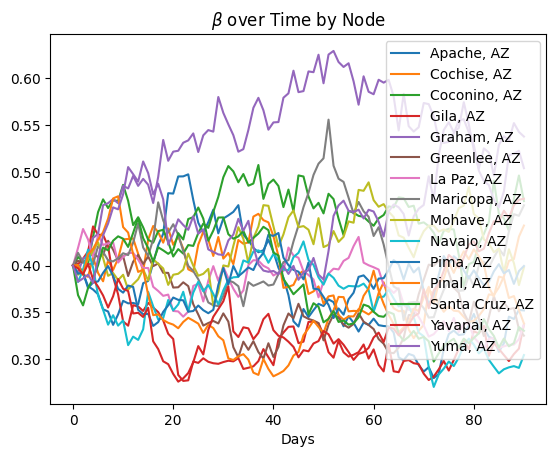

In [2]:
scope = CountyScope.in_states(["AZ"], year=2015)
sim_movement_model = mm.Centroids()
sim_ipm = ipm.SIRH()
sim_time_frame = TimeFrame.of("2015-01-01", 13 * 7)
gen_rng = np.random.default_rng(0)

"""Generate a random time dependent beta"""

log_beta_damping = 1 / 35 * np.ones(scope.nodes)
log_beta_mean = np.log(0.4) * np.ones(scope.nodes)
log_beta_standard_deviation = 0.15 * np.ones(scope.nodes)
initial_log_beta = np.log(0.4) * np.ones(scope.nodes)

delta_t = 1.0

A = np.exp(-log_beta_damping * delta_t)
M = log_beta_mean * (np.exp(-log_beta_damping * delta_t) - 1)
C = log_beta_standard_deviation * np.sqrt(1 - np.exp(-2 * log_beta_damping * delta_t))

log_beta = np.zeros(
    (
        scope.nodes,
        sim_time_frame.duration_days,
    )
)
log_beta[:, 0] = initial_log_beta

for day in range(1, sim_time_frame.duration_days):
    log_beta[:, day] = (
        A * log_beta[:, day - 1] - M + C * gen_rng.normal(size=(scope.nodes,))
    )

beta = np.exp(log_beta)

plt.title("$\\beta$ over Time by Node")
plt.xlabel("Days")
for node in range(scope.nodes):
    plt.plot(beta[node, :], label=f"{scope.labels[node]}")
plt.legend()
plt.show()

In [3]:
rume = SingleStrataRUME.build(
    ipm=sim_ipm,
    mm=sim_movement_model,
    scope=scope,
    init=init.IndexedLocations(selection=np.arange(scope.nodes), seed_size=10_000),
    time_frame=sim_time_frame,
    params={
        "beta": beta.T,
        "gamma": 0.1,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 0.05,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

Loading gpm:all::mm::population (epymorph.adrio.acs5.Population):
  |####################| 100%  (0.663s)
Running simulation (BasicSimulator):
• 2015-01-01 to 2015-04-01 (91 days)
• 15 geo nodes
  |####################| 100%                    
Runtime: 0.271s


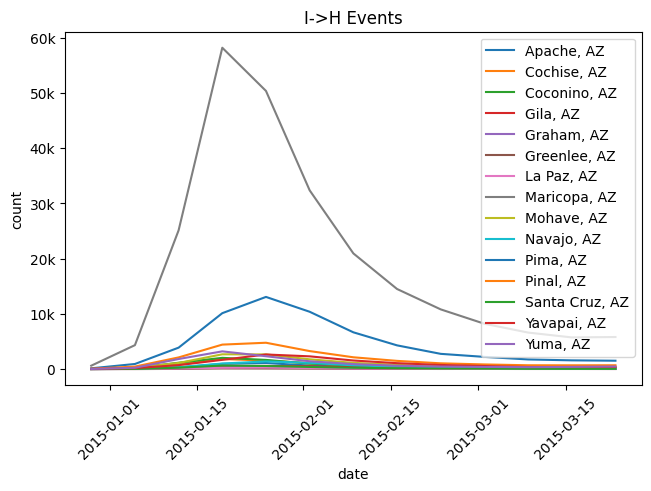

In [4]:
sim = BasicSimulator(rume)

with sim_messaging():
    out = sim.run(rng_factory=lambda: gen_rng)

out.plot.line(
    geo=rume.scope.select.all(),
    time=rume.time_frame.select.all().group("week").agg(),
    quantity=rume.ipm.select.events("I->H"),
    title="I->H Events",
    label_format="{n}",
    legend="on",
)

In [5]:
from epymorph.util import to_date_value_array
from epymorph.tools.data import munge

cases_df = munge(
    out,
    quantity=rume.ipm.select.events("I->H"),
    time=rume.time_frame.select.all().group("week").agg(),
    geo=rume.scope.select.all(),
)

cases_arr = to_date_value_array(
    cases_df["time"].to_numpy(), cases_df["I → H"].to_numpy()
).reshape(-1, rume.scope.nodes)

In [6]:
from epymorph.forecasting.dynamic_params import OrnsteinUhlenbeck
from epymorph.forecasting.likelihood import NegativeBinomialLikelihood


my_observations = Observations(
    source=cases_arr,
    model_link=ModelLink(
        geo=rume.scope.select.all(),
        time=rume.time_frame.select.all().group("week").agg(),
        quantity=rume.ipm.select.events("I->H"),
    ),
    likelihood=NegativeBinomialLikelihood(r=10.0),
)

my_unknown_params = {
    "log_beta": UnknownParam(
        prior=GaussianPrior(
            mean=log_beta_mean,
            standard_deviation=log_beta_standard_deviation,
        ),
        dynamics=OrnsteinUhlenbeck(
            damping=log_beta_damping,
            mean=log_beta_mean,
            standard_deviation=log_beta_standard_deviation,
        ),
    )
}

In [7]:

num_realizations = 100

inf_rume = SingleStrataRUME.build(
    ipm=sim_ipm,
    mm=sim_movement_model,
    scope=scope,
    init=RandomLocationsAndRandomSeed(scope.nodes, 50_000),
    time_frame=sim_time_frame,
    params={
        "beta": ExponentialTransform("log_beta"),
        "gamma": 0.1,
        "xi": 1 / 90,
        "phi": 5,
        "hospitalization_prob": 0.05,
        "hospitalization_duration": 5,
        "centroid": us_tiger.InternalPoint(),
        "population": acs5.Population(),
        "label": us_tiger.Name(),
    },
)

particle_filter_simulator = ParticleFilterSimulator(
    config=PipelineConfig.from_rume(
        inf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=my_observations,
)

ensemble_kalman_filter_simulator = EnsembleKalmanFilterSimulator(
    config=PipelineConfig.from_rume(
        inf_rume, num_realizations, unknown_params=my_unknown_params
    ),
    observations=my_observations,
)

In [8]:
rng0 = np.random.default_rng(0)
particle_filter_output = particle_filter_simulator.run(rng=rng0)

rng1 = np.random.default_rng(0)
ensemble_kalman_filter_output = ensemble_kalman_filter_simulator.run(rng=rng1)

Observation: 0, Label: 2014-12-29, Time Frame: 2015-01-01/2015-01-04 (4D)
Observation: 1, Label: 2015-01-05, Time Frame: 2015-01-05/2015-01-11 (7D)
Observation: 2, Label: 2015-01-12, Time Frame: 2015-01-12/2015-01-18 (7D)
Observation: 3, Label: 2015-01-19, Time Frame: 2015-01-19/2015-01-25 (7D)
Observation: 4, Label: 2015-01-26, Time Frame: 2015-01-26/2015-02-01 (7D)
Observation: 5, Label: 2015-02-02, Time Frame: 2015-02-02/2015-02-08 (7D)
Observation: 6, Label: 2015-02-09, Time Frame: 2015-02-09/2015-02-15 (7D)
Observation: 7, Label: 2015-02-16, Time Frame: 2015-02-16/2015-02-22 (7D)
Observation: 8, Label: 2015-02-23, Time Frame: 2015-02-23/2015-03-01 (7D)
Observation: 9, Label: 2015-03-02, Time Frame: 2015-03-02/2015-03-08 (7D)
Observation: 10, Label: 2015-03-09, Time Frame: 2015-03-09/2015-03-15 (7D)
Observation: 11, Label: 2015-03-16, Time Frame: 2015-03-16/2015-03-22 (7D)
Observation: 12, Label: 2015-03-23, Time Frame: 2015-03-23/2015-03-29 (7D)
Observation: 13, Label: 2015-03-30,

ZeroDivisionError: integer division or modulo by zero

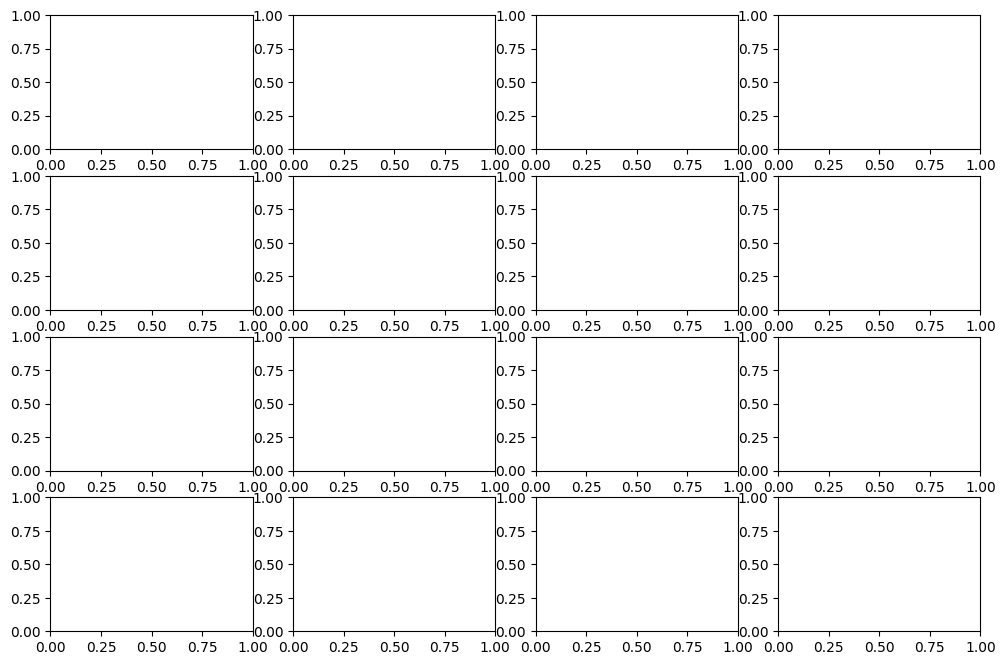

In [10]:
from epymorph.forecasting.filter_plot import PlotRendererPipeline

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 8))
quantity = rume.ipm.select.compartments("I")
geo = rume.scope.select.all()
time = rume.time_frame.select.days(100, 100).group("day").agg()

pf_plotter = PlotRendererPipeline(particle_filter_output)
enkf_plotter = PlotRendererPipeline(ensemble_kalman_filter_output)

def scale_transform(data_df):
    mean = np.mean(data_df["value"])
    std = np.std(data_df["value"])
    value = data_df["value"].apply(lambda x: (x - mean)/std)
    return data_df.assign(value=value)

pf_plotter.kde_plt(
    np.array([axes]),
    geo,
    time,
    quantity,
    legend="on",
    label_format="PF: {q}",
    bandwidth="scott",
    delta_t = 0.1,
    kwarg_type="geo",
    transform=scale_transform
)

enkf_plotter.kde_plt(
    np.array([axes]),
    geo,
    time,
    quantity,
    legend="on",
    label_format="EnKF: {q}",
    bandwidth="scott",
    delta_t = 0.1,
    kwarg_type="geo",
    transform=scale_transform
)

fig.tight_layout()
plt.show()